#CVIU Experiment 1:D1 Random 75%/25% Split

This notebook evaluates two baselines and four neural-network models on a random split of D1.

The evaluated methods are:

- **Naive Prediction:**the mean target distribution of the training subset
- **ED Regression:**nonlinear regression based on CIELAB ΔEab
- **M1:Siamese**
- **M2:Siamese+Lab**
- **M3:Siamese+ΔE**
- **M4:Siamese+ΔE+Lab**

The neural networks are implemented separately so that the structure and input combination of each model can be inspected independently.

The notebook performs data loading, preprocessing, random splitting, model training, evaluation, result export, and summary generation in one run.


##1.Setup

In [2]:
import gc
import json
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=RuntimeWarning)

print("PyTorch:", torch.__version__)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", DEVICE)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

PyTorch: 2.11.0+cu128
Device: cuda


##2.Parameters

This cell contains all configurable experiment parameters, including file paths, output location, random splitting, preprocessing, neural-network architecture, optimization, regularization, scheduler behavior, and regression settings.

In [ ]:
#File paths
D1_PATH = (
    ""
) #Please fill the path

OUTPUT_DIR = Path(
    ""
) #Please fill the path
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

#Random split
SEED = 42
TEST_SIZE = 0.25

#Preprocessing
#Options: "full_d1" or "training_only"
NORMALIZATION_SCOPE = "full_d1"

#Shared neural-network architecture
ENCODER_LAYERS = [
    32,
    64,
    64,
    64,
    64,
]

REGRESSOR_LAYERS = [
    32,
    32,
    16,
    8,
]

#Training
EPOCHS = 300
BATCH_SIZE = 8
LEARNING_RATE = 5e-4
INPUT_NOISE_STD = 0.01
WEIGHT_DECAY = 0.0
PRINT_EVERY = 25

#Direct Lab-feature weights
M2_LAB_WEIGHT = 0.01
M4_LAB_WEIGHT = 0.01

#Learning-rate scheduler
USE_SCHEDULER = True
#Options: "training" or "validation"
SCHEDULER_MONITOR = "training"
SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 50
SCHEDULER_THRESHOLD = 1e-3
MIN_LEARNING_RATE = 1e-6

#Regression
REGRESSION_MAX_FUNCTION_EVALUATIONS = 20000
REGRESSION_EPSILON = 1e-7

#Output
SAVE_MODEL_WEIGHTS = True
SAVE_PREDICTIONS = True

print("Output directory:", OUTPUT_DIR)

Output directory: /content/drive/MyDrive/CVIU_Experiment1_D1_Random_75_25


##3.Data preparation

In [4]:
def read_csv_auto(path):
    return pd.read_csv(
        path,
        sep=None,
        engine="python",
        header=0,
    )


def normalize_response_values(response_array):
    values = set(
        pd.unique(
            response_array.ravel()
        )
    )

    values = {
        value
        for value in values
        if not pd.isna(value)
    }

    if values.issubset({0, 1, 2}):
        return response_array

    if values.issubset({1, 2, 3}):
        return response_array - 1

    raise ValueError(
        "Observer responses must use "
        "either {0,1,2} or {1,2,3}. "
        f"Detected values: {sorted(values)}"
    )


def add_probability_columns(
    dataframe,
    response_columns,
):
    dataframe = dataframe.copy()

    probability_sets = [
        (
            "possibility0",
            "possibility1",
            "possibility2",
        ),
        (
            "probability0",
            "probability1",
            "probability2",
        ),
        (
            "p0",
            "p1",
            "p2",
        ),
        (
            "true1",
            "true2",
            "true3",
        ),
    ]

    for columns in probability_sets:
        if all(
            column in dataframe.columns
            for column in columns
        ):
            probabilities = dataframe.loc[
                :,
                columns,
            ].to_numpy(
                dtype=np.float32
            )

            probabilities = (
                probabilities
                / np.clip(
                    probabilities.sum(
                        axis=1,
                        keepdims=True,
                    ),
                    1e-8,
                    None,
                )
            )

            dataframe[
                "possibility0"
            ] = probabilities[:, 0]

            dataframe[
                "possibility1"
            ] = probabilities[:, 1]

            dataframe[
                "possibility2"
            ] = probabilities[:, 2]

            return dataframe

    if not response_columns:
        raise ValueError(
            "No observer-response columns "
            "or probability columns were found."
        )

    responses = dataframe.loc[
        :,
        response_columns,
    ].to_numpy(
        dtype=np.float32
    )

    responses = normalize_response_values(
        responses
    )

    denominator = len(
        response_columns
    )

    for category in [0, 1, 2]:
        dataframe[
            f"possibility{category}"
        ] = (
            responses == category
        ).sum(
            axis=1
        ) / denominator

    return dataframe


def detect_feature_columns(
    dataframe,
    response_columns,
):
    explicit_sets = [
        [
            "L1",
            "a1",
            "b1",
            "L2",
            "a2",
            "b2",
        ],
        [
            "L_1",
            "a_1",
            "b_1",
            "L_2",
            "a_2",
            "b_2",
        ],
        [
            "L1*",
            "a1*",
            "b1*",
            "L2*",
            "a2*",
            "b2*",
        ],
    ]

    for columns in explicit_sets:
        if all(
            column in dataframe.columns
            for column in columns
        ):
            return columns

    excluded_columns = {
        "C1",
        "C2",
        "Average",
        "possibility0",
        "possibility1",
        "possibility2",
        *response_columns,
    }

    numeric_candidates = [
        column
        for column in dataframe.columns
        if column not in excluded_columns
        and pd.api.types.is_numeric_dtype(
            dataframe[column]
        )
    ]

    if len(numeric_candidates) < 6:
        raise ValueError(
            "Could not identify six Lab columns. "
            f"Candidates: {numeric_candidates}"
        )

    return numeric_candidates[:6]


def prepare_xy(
    dataframe,
    response_columns,
):
    prepared = add_probability_columns(
        dataframe,
        response_columns,
    )

    feature_columns = detect_feature_columns(
        prepared,
        response_columns,
    )

    X = prepared.loc[
        :,
        feature_columns,
    ].to_numpy(
        dtype=np.float32
    )

    Y = prepared.loc[
        :,
        [
            "possibility0",
            "possibility1",
            "possibility2",
        ],
    ].to_numpy(
        dtype=np.float32
    )

    Y = (
        Y
        / np.clip(
            Y.sum(
                axis=1,
                keepdims=True,
            ),
            1e-8,
            None,
        )
    )

    return (
        X,
        Y,
        prepared,
        feature_columns,
    )


d1_dataframe = read_csv_auto(
    D1_PATH
)

d1_response_columns = [
    str(index)
    for index in range(1, 21)
    if str(index)
    in d1_dataframe.columns
]

(
    X_raw,
    Y,
    d1_prepared,
    FEATURE_COLUMNS,
) = prepare_xy(
    d1_dataframe,
    d1_response_columns,
)

assert len(X_raw) == 800, (
    f"Expected 800 D1 samples, "
    f"got {len(X_raw)}."
)

all_indices = np.arange(
    len(X_raw)
)

(
    train_indices,
    test_indices,
) = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True,
)

X_train_raw = X_raw[
    train_indices
]

Y_train = Y[
    train_indices
]

X_test_raw = X_raw[
    test_indices
]

Y_test = Y[
    test_indices
]

if NORMALIZATION_SCOPE == "full_d1":
    normalization_reference = X_raw

elif NORMALIZATION_SCOPE == "training_only":
    normalization_reference = (
        X_train_raw
    )

else:
    raise ValueError(
        "NORMALIZATION_SCOPE must be "
        "'full_d1' or 'training_only'."
    )

FEATURE_MIN = (
    normalization_reference.min(
        axis=0
    )
)

FEATURE_MAX = (
    normalization_reference.max(
        axis=0
    )
)


def normalize_features(X):
    return (
        X - FEATURE_MIN
    ) / (
        FEATURE_MAX
        - FEATURE_MIN
        + 1e-8
    )


X_train = normalize_features(
    X_train_raw
).astype(
    np.float32
)

X_test = normalize_features(
    X_test_raw
).astype(
    np.float32
)

normalized_reference = normalize_features(
    normalization_reference
)

delta_reference = np.linalg.norm(
    normalized_reference[:, :3]
    - normalized_reference[:, 3:],
    axis=1,
)

DELTA_E_MIN = float(
    delta_reference.min()
)

DELTA_E_MAX = float(
    delta_reference.max()
)

print(
    "Feature columns:",
    FEATURE_COLUMNS,
)

print(
    "Training samples:",
    len(X_train),
)

print(
    "Test samples:",
    len(X_test),
)

print(
    "Training target mean:",
    Y_train.mean(axis=0),
)

print(
    "Test target mean:",
    Y_test.mean(axis=0),
)

Feature columns: ['L1', 'a1', 'b1', 'L2', 'a2', 'b2']
Training samples: 600
Test samples: 200
Training target mean: [0.03916666 0.14408334 0.8167498 ]
Test target mean: [0.02874999 0.13099998 0.8402497 ]


##4.Shared training components

In [5]:
class ColorPairDataset(Dataset):

    def __init__(
        self,
        X,
        Y,
        noise_std=0.0,
    ):
        self.X = torch.tensor(
            X,
            dtype=torch.float32,
        )

        self.Y = torch.tensor(
            Y,
            dtype=torch.float32,
        )

        self.noise_std = float(
            noise_std
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        x = self.X[
            index
        ].clone()

        if self.noise_std > 0:
            x = (
                x
                + torch.randn_like(x)
                * self.noise_std
            )

        return (
            x,
            self.Y[index],
        )


class SoftCrossEntropyLoss(nn.Module):

    def forward(
        self,
        logits,
        targets,
    ):
        log_probabilities = (
            torch.log_softmax(
                logits,
                dim=1,
            )
        )

        return -(
            targets
            * log_probabilities
        ).sum(
            dim=1
        ).mean()


criterion = SoftCrossEntropyLoss()


class SharedEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        modules = []
        input_size = 3

        for index, output_size in enumerate(
            ENCODER_LAYERS
        ):
            modules.append(
                nn.Linear(
                    input_size,
                    output_size,
                )
            )

            if (
                index
                < len(
                    ENCODER_LAYERS
                ) - 1
            ):
                modules.append(
                    nn.ReLU()
                )

            input_size = output_size

        self.network = nn.Sequential(
            *modules
        )

    def forward(self, x):
        return self.network(x)


def build_regressor(
    input_size,
):
    modules = []
    current_size = input_size

    for hidden_size in (
        REGRESSOR_LAYERS
    ):
        modules.append(
            nn.Linear(
                current_size,
                hidden_size,
            )
        )

        modules.append(
            nn.ReLU()
        )

        current_size = hidden_size

    modules.append(
        nn.Linear(
            current_size,
            3,
        )
    )

    return nn.Sequential(
        *modules
    )


def calculate_siamese_distance(
    encoder,
    x,
):
    color1 = x[:, :3]
    color2 = x[:, 3:]

    embedding1 = encoder(
        color1
    )

    embedding2 = encoder(
        color2
    )

    return torch.linalg.norm(
        embedding1 - embedding2,
        dim=1,
        keepdim=True,
    )


def calculate_delta_e(
    x,
):
    color1 = x[:, :3]
    color2 = x[:, 3:]

    delta_e = torch.linalg.norm(
        color1 - color2,
        dim=1,
        keepdim=True,
    )

    return (
        delta_e - DELTA_E_MIN
    ) / (
        DELTA_E_MAX
        - DELTA_E_MIN
        + 1e-8
    )


def make_loader(
    X,
    Y,
    shuffle,
    noise_std,
    seed,
):
    generator = torch.Generator()
    generator.manual_seed(
        seed
    )

    return DataLoader(
        ColorPairDataset(
            X,
            Y,
            noise_std=noise_std,
        ),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        generator=generator,
    )


def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter
        in model.parameters()
        if parameter.requires_grad
    )

##5.Method definitions

###5-1.Naive Prediction

Naive Prediction uses the mean target distribution of the D1 training subset as the prediction for every test sample.

In [6]:
def run_naive(
    Y_training,
    Y_testing,
):
    mean_distribution = Y_training.mean(
        axis=0
    )

    training_predictions = np.repeat(
        mean_distribution.reshape(1, -1),
        len(Y_training),
        axis=0,
    )

    testing_predictions = np.repeat(
        mean_distribution.reshape(1, -1),
        len(Y_testing),
        axis=0,
    )

    training_loss = cross_entropy_numpy(
        Y_training,
        training_predictions,
    )

    testing_loss = cross_entropy_numpy(
        Y_testing,
        testing_predictions,
    )

    result = {
        "Model": "Naive",
        "Method": "Training mean distribution",
        "Trainable parameters": 0,
        "Training loss": training_loss,
        "Test loss": testing_loss,
        "Best test loss": testing_loss,
        "Best epoch": np.nan,
        "Final learning rate": np.nan,
    }

    return (
        result,
        testing_predictions.astype(
            np.float32
        ),
        mean_distribution.astype(
            np.float32
        ),
    )


###5-2.ED Regression

The regression baseline uses the CIELAB ΔEab value of each color pair as its independent variable. Three nonlinear curves are fitted independently to predict the three response probabilities.

In [7]:
def nonlinear_regression_function(
    x,
    coefficient,
    exponent_coefficient,
):
    safe_x = np.maximum(
        x,
        1e-16,
    )

    exponent = np.clip(
        exponent_coefficient
        / safe_x,
        -8.0,
        8.0,
    )

    return (
        coefficient
        * np.exp(exponent)
    )


def make_probability_distribution(
    raw_predictions,
):
    predictions = np.asarray(
        raw_predictions,
        dtype=np.float64,
    )

    predictions = np.clip(
        predictions,
        REGRESSION_EPSILON,
        None,
    )

    predictions = (
        predictions
        / np.clip(
            predictions.sum(
                axis=1,
                keepdims=True,
            ),
            REGRESSION_EPSILON,
            None,
        )
    )

    return predictions.astype(
        np.float32
    )


def cross_entropy_numpy(
    targets,
    predictions,
):
    predictions = np.clip(
        predictions,
        REGRESSION_EPSILON,
        1.0,
    )

    return float(
        np.mean(
            -np.sum(
                targets
                * np.log(
                    predictions
                ),
                axis=1,
            )
        )
    )


def run_regression(
    X_training_raw,
    Y_training,
    X_testing_raw,
    Y_testing,
):
    training_delta_e = (
        np.linalg.norm(
            X_training_raw[:, :3]
            - X_training_raw[:, 3:],
            axis=1,
        )
    )

    testing_delta_e = (
        np.linalg.norm(
            X_testing_raw[:, :3]
            - X_testing_raw[:, 3:],
            axis=1,
        )
    )

    fitted_parameters = []

    for category in range(3):
        try:
            parameters, _ = curve_fit(
                nonlinear_regression_function,
                training_delta_e,
                Y_training[:, category],
                maxfev=(
                    REGRESSION_MAX_FUNCTION_EVALUATIONS
                ),
            )

        except Exception:
            parameters, _ = curve_fit(
                nonlinear_regression_function,
                training_delta_e,
                Y_training[:, category],
                p0=[
                    max(
                        float(
                            Y_training[
                                :,
                                category,
                            ].mean()
                        ),
                        1e-3,
                    ),
                    -1.0,
                ],
                maxfev=(
                    REGRESSION_MAX_FUNCTION_EVALUATIONS
                    * 2
                ),
            )

        fitted_parameters.append(
            parameters
        )

    training_raw_predictions = (
        np.stack(
            [
                nonlinear_regression_function(
                    training_delta_e,
                    *fitted_parameters[
                        category
                    ],
                )
                for category in range(3)
            ],
            axis=1,
        )
    )

    testing_raw_predictions = (
        np.stack(
            [
                nonlinear_regression_function(
                    testing_delta_e,
                    *fitted_parameters[
                        category
                    ],
                )
                for category in range(3)
            ],
            axis=1,
        )
    )

    training_predictions = (
        make_probability_distribution(
            training_raw_predictions
        )
    )

    testing_predictions = (
        make_probability_distribution(
            testing_raw_predictions
        )
    )

    training_loss = cross_entropy_numpy(
        Y_training,
        training_predictions,
    )

    testing_loss = cross_entropy_numpy(
        Y_testing,
        testing_predictions,
    )

    result = {
        "Model": "Regression",
        "Method": "ED Regression",
        "Trainable parameters": 6,
        "Training loss": training_loss,
        "Test loss": testing_loss,
        "Best test loss": testing_loss,
        "Best epoch": np.nan,
        "Final learning rate": np.nan,
    }

    return (
        result,
        testing_predictions,
        fitted_parameters,
    )

###5-3.M1:Siamese

M1 encodes each color independently with a shared encoder. The Euclidean distance between the two embeddings is used as the only input to the prediction network.

In [8]:
class M1Siamese(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = SharedEncoder()
        self.regressor = (
            build_regressor(
                input_size=1
            )
        )

    def forward(self, x):
        siamese_distance = (
            calculate_siamese_distance(
                self.encoder,
                x,
            )
        )

        return self.regressor(
            siamese_distance
        )

###5-4.M2:Siamese+Lab

M2 concatenates the Siamese distance with the two normalized Lab coordinate triplets before prediction.

In [9]:
class M2SiameseLab(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = SharedEncoder()
        self.regressor = (
            build_regressor(
                input_size=7
            )
        )

    def forward(self, x):
        siamese_distance = (
            calculate_siamese_distance(
                self.encoder,
                x,
            )
        )

        weighted_lab = (
            x * M2_LAB_WEIGHT
        )

        features = torch.cat(
            [
                siamese_distance,
                weighted_lab,
            ],
            dim=1,
        )

        return self.regressor(
            features
        )

###5-5.M3:Siamese+ΔE

M3 concatenates the Siamese distance with the normalized ΔE value calculated from the input color pair.

In [10]:
class M3SiameseDeltaE(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = SharedEncoder()
        self.regressor = (
            build_regressor(
                input_size=2
            )
        )

    def forward(self, x):
        siamese_distance = (
            calculate_siamese_distance(
                self.encoder,
                x,
            )
        )

        delta_e = (
            calculate_delta_e(x)
        )

        features = torch.cat(
            [
                siamese_distance,
                delta_e,
            ],
            dim=1,
        )

        return self.regressor(
            features
        )

###5-6.M4:Siamese+ΔE+Lab

M4 combines the Siamese distance, normalized ΔE, and the two normalized Lab coordinate triplets.

In [11]:
class M4SiameseDeltaELab(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = SharedEncoder()
        self.regressor = (
            build_regressor(
                input_size=8
            )
        )

    def forward(self, x):
        siamese_distance = (
            calculate_siamese_distance(
                self.encoder,
                x,
            )
        )

        delta_e = (
            calculate_delta_e(x)
        )

        weighted_lab = (
            x * M4_LAB_WEIGHT
        )

        features = torch.cat(
            [
                siamese_distance,
                delta_e,
                weighted_lab,
            ],
            dim=1,
        )

        return self.regressor(
            features
        )

##6.Training and evaluation

In [12]:
def evaluate_neural_model(
    model,
    loader,
    return_predictions=False,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0
    all_probabilities = []

    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(
                DEVICE
            )

            Y_batch = Y_batch.to(
                DEVICE
            )

            logits = model(
                X_batch
            )

            loss = criterion(
                logits,
                Y_batch,
            )

            batch_size = (
                X_batch.size(0)
            )

            total_loss += (
                loss.item()
                * batch_size
            )

            total_samples += (
                batch_size
            )

            if return_predictions:
                probabilities = (
                    torch.softmax(
                        logits,
                        dim=1,
                    )
                )

                all_probabilities.append(
                    probabilities.cpu().numpy()
                )

    average_loss = (
        total_loss
        / total_samples
    )

    if return_predictions:
        return (
            average_loss,
            np.concatenate(
                all_probabilities,
                axis=0,
            ),
        )

    return average_loss


def train_neural_model(
    model_name,
    method_name,
    model_class,
):
    set_seed(SEED)

    model = model_class().to(
        DEVICE
    )

    training_loader = make_loader(
        X_train,
        Y_train,
        shuffle=True,
        noise_std=INPUT_NOISE_STD,
        seed=SEED,
    )

    clean_training_loader = (
        make_loader(
            X_train,
            Y_train,
            shuffle=False,
            noise_std=0.0,
            seed=SEED,
        )
    )

    testing_loader = make_loader(
        X_test,
        Y_test,
        shuffle=False,
        noise_std=0.0,
        seed=SEED,
    )

    if WEIGHT_DECAY > 0:
        optimizer = optim.AdamW(
            model.parameters(),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
        )

    else:
        optimizer = optim.Adam(
            model.parameters(),
            lr=LEARNING_RATE,
        )

    if USE_SCHEDULER:
        scheduler = (
            optim.lr_scheduler
            .ReduceLROnPlateau(
                optimizer,
                mode="min",
                factor=(
                    SCHEDULER_FACTOR
                ),
                patience=(
                    SCHEDULER_PATIENCE
                ),
                threshold=(
                    SCHEDULER_THRESHOLD
                ),
                min_lr=(
                    MIN_LEARNING_RATE
                ),
            )
        )

    else:
        scheduler = None

    history_rows = []
    best_test_loss = float("inf")
    best_epoch = None
    best_state = None

    print()
    print("=" * 80)
    print(
        model_name,
        method_name,
    )

    print(
        "Trainable parameters:",
        count_parameters(model),
    )

    for epoch in range(
        1,
        EPOCHS + 1,
    ):
        model.train()

        total_noisy_loss = 0.0
        total_samples = 0
        epoch_start = time.time()

        for (
            X_batch,
            Y_batch,
        ) in training_loader:
            X_batch = X_batch.to(
                DEVICE
            )

            Y_batch = Y_batch.to(
                DEVICE
            )

            optimizer.zero_grad()

            logits = model(
                X_batch
            )

            loss = criterion(
                logits,
                Y_batch,
            )

            loss.backward()
            optimizer.step()

            batch_size = (
                X_batch.size(0)
            )

            total_noisy_loss += (
                loss.item()
                * batch_size
            )

            total_samples += (
                batch_size
            )

        noisy_training_loss = (
            total_noisy_loss
            / total_samples
        )

        clean_training_loss = (
            evaluate_neural_model(
                model,
                clean_training_loader,
            )
        )

        test_loss = (
            evaluate_neural_model(
                model,
                testing_loader,
            )
        )

        if test_loss < best_test_loss:
            best_test_loss = (
                test_loss
            )

            best_epoch = epoch

            best_state = {
                key:
                    value.detach()
                    .cpu()
                    .clone()
                for key, value
                in model.state_dict().items()
            }

        if scheduler is not None:
            if (
                SCHEDULER_MONITOR
                == "training"
            ):
                scheduler.step(
                    noisy_training_loss
                )

            elif (
                SCHEDULER_MONITOR
                == "validation"
            ):
                scheduler.step(
                    test_loss
                )

            else:
                raise ValueError(
                    "SCHEDULER_MONITOR "
                    "must be 'training' "
                    "or 'validation'."
                )

        current_learning_rate = (
            optimizer.param_groups[
                0
            ]["lr"]
        )

        history_rows.append({
            "Model": model_name,
            "Method": method_name,
            "Epoch": epoch,
            "Noisy training loss":
                noisy_training_loss,
            "Clean training loss":
                clean_training_loss,
            "Test loss":
                test_loss,
            "Learning rate":
                current_learning_rate,
        })

        if (
            epoch == 1
            or epoch % PRINT_EVERY == 0
            or epoch == EPOCHS
        ):
            elapsed = (
                time.time()
                - epoch_start
            )

            print(
                f"Epoch {epoch:4d} "
                f"train="
                f"{clean_training_loss:.6f} "
                f"test="
                f"{test_loss:.6f} "
                f"lr="
                f"{current_learning_rate:.2e} "
                f"time="
                f"{elapsed:.3f}s"
            )

    final_training_loss = (
        evaluate_neural_model(
            model,
            clean_training_loader,
        )
    )

    (
        final_test_loss,
        final_predictions,
    ) = evaluate_neural_model(
        model,
        testing_loader,
        return_predictions=True,
    )

    if (
        SAVE_MODEL_WEIGHTS
        and best_state is not None
    ):
        torch.save(
            best_state,
            OUTPUT_DIR
            / (
                f"{model_name}_"
                "best_state.pt"
            ),
        )

        torch.save(
            model.state_dict(),
            OUTPUT_DIR
            / (
                f"{model_name}_"
                "final_state.pt"
            ),
        )

    result = {
        "Model": model_name,
        "Method": method_name,
        "Trainable parameters":
            count_parameters(model),
        "Training loss":
            final_training_loss,
        "Test loss":
            final_test_loss,
        "Best test loss":
            best_test_loss,
        "Best epoch":
            best_epoch,
        "Final learning rate":
            optimizer.param_groups[
                0
            ]["lr"],
    }

    return (
        result,
        pd.DataFrame(
            history_rows
        ),
        final_predictions,
        model,
    )


def release_model(model):
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

##7.One-click execution

Running Naive Prediction...
Running ED Regression...

M1 Siamese
Trainable parameters: 16531
Epoch    1 train=0.753551 test=0.733318 lr=5.00e-04 time=1.304s
Epoch   25 train=0.451486 test=0.430320 lr=5.00e-04 time=0.405s
Epoch   50 train=0.440267 test=0.424461 lr=5.00e-04 time=0.420s
Epoch   75 train=0.421078 test=0.410574 lr=5.00e-04 time=0.409s
Epoch  100 train=0.405050 test=0.401383 lr=5.00e-04 time=0.421s
Epoch  125 train=0.395938 test=0.387584 lr=5.00e-04 time=0.410s
Epoch  150 train=0.387647 test=0.383633 lr=5.00e-04 time=0.411s
Epoch  175 train=0.388320 test=0.378028 lr=5.00e-04 time=0.408s
Epoch  200 train=0.389104 test=0.380137 lr=5.00e-04 time=0.411s
Epoch  225 train=0.386135 test=0.377044 lr=5.00e-04 time=0.406s
Epoch  250 train=0.385459 test=0.374082 lr=5.00e-04 time=0.416s
Epoch  275 train=0.386751 test=0.375596 lr=5.00e-04 time=0.423s
Epoch  300 train=0.383302 test=0.375894 lr=5.00e-04 time=0.409s

M2 Siamese+Lab
Trainable parameters: 16723
Epoch    1 train=0.778224 test=

,Rank,Model,Method,Trainable parameters,Training loss,Test loss,Best test loss,Best epoch,Final learning rate
0,1,M4,Siamese+ΔE+Lab,16755,0.379611,0.368057,0.367882,200.0,0.000125
1,2,M3,Siamese+ΔE,16563,0.382643,0.370841,0.367988,286.0,0.000500
2,3,M2,Siamese+Lab,16723,0.379910,0.373324,0.367670,132.0,0.000250
3,4,M1,Siamese,16531,0.383302,0.375894,0.371063,289.0,0.000500
4,5,Regression,ED Regression,6,0.470114,0.448914,0.448914,NaN,NaN
5,6,Naive,Training mean distribution,0,0.571368,0.517028,0.517028,NaN,NaN


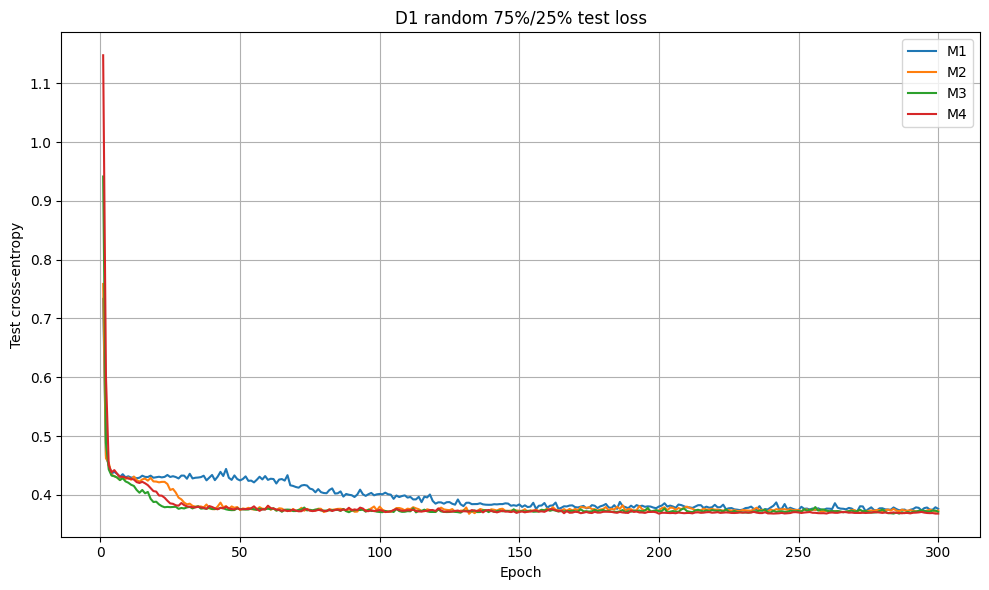


##8.Result summary

The D1 dataset was randomly divided into a training subset and a test subset. Naive Prediction, one nonlinear ΔEab regression baseline, and four separately implemented neural-network models were evaluated using categorical cross-entropy.

The best final result was obtained by **M4:Siamese+ΔE+Lab**, with a test loss of **0.368057**.

The final losses were:

- Naive Prediction: 0.517028
- ED Regression: 0.448914
- M1:Siamese: 0.375894
- M2:Siamese+Lab: 0.373324
- M3:Siamese+ΔE: 0.370841
- M4:Siamese+ΔE+Lab: 0.368057

M4 achieved a lower final test loss than M3.

The complete results, training histories, split information, predictions, model checkpoints, parameter settings, and loss curves were saved to the output directory.



Completed.
Files saved to:
/content/drive/MyDrive/CVIU_Experiment1_D1_Random_75_25


In [13]:
def run_experiment():
    result_rows = []
    history_frames = []
    prediction_frames = []

    print(
        "Running Naive Prediction..."
    )

    (
        naive_result,
        naive_predictions,
        naive_distribution,
    ) = run_naive(
        Y_train,
        Y_test,
    )

    result_rows.append(
        naive_result
    )

    prediction_frames.append(
        pd.DataFrame({
            "Sample index":
                test_indices,
            "Model":
                "Naive",
            "True 0":
                Y_test[:, 0],
            "True 1":
                Y_test[:, 1],
            "True 2":
                Y_test[:, 2],
            "Predicted 0":
                naive_predictions[:, 0],
            "Predicted 1":
                naive_predictions[:, 1],
            "Predicted 2":
                naive_predictions[:, 2],
        })
    )

    print(
        "Running ED Regression..."
    )

    (
        regression_result,
        regression_predictions,
        regression_parameters,
    ) = run_regression(
        X_train_raw,
        Y_train,
        X_test_raw,
        Y_test,
    )

    result_rows.append(
        regression_result
    )

    prediction_frames.append(
        pd.DataFrame({
            "Sample index":
                test_indices,
            "Model":
                "Regression",
            "True 0":
                Y_test[:, 0],
            "True 1":
                Y_test[:, 1],
            "True 2":
                Y_test[:, 2],
            "Predicted 0":
                regression_predictions[
                    :,
                    0
                ],
            "Predicted 1":
                regression_predictions[
                    :,
                    1
                ],
            "Predicted 2":
                regression_predictions[
                    :,
                    2
                ],
        })
    )

    neural_models = [
        (
            "M1",
            "Siamese",
            M1Siamese,
        ),
        (
            "M2",
            "Siamese+Lab",
            M2SiameseLab,
        ),
        (
            "M3",
            "Siamese+ΔE",
            M3SiameseDeltaE,
        ),
        (
            "M4",
            "Siamese+ΔE+Lab",
            M4SiameseDeltaELab,
        ),
    ]

    for (
        model_name,
        method_name,
        model_class,
    ) in neural_models:
        (
            result,
            history,
            predictions,
            model,
        ) = train_neural_model(
            model_name,
            method_name,
            model_class,
        )

        result_rows.append(
            result
        )

        history_frames.append(
            history
        )

        prediction_frames.append(
            pd.DataFrame({
                "Sample index":
                    test_indices,
                "Model":
                    model_name,
                "True 0":
                    Y_test[:, 0],
                "True 1":
                    Y_test[:, 1],
                "True 2":
                    Y_test[:, 2],
                "Predicted 0":
                    predictions[:, 0],
                "Predicted 1":
                    predictions[:, 1],
                "Predicted 2":
                    predictions[:, 2],
            })
        )

        release_model(model)

    results = (
        pd.DataFrame(
            result_rows
        )
        .sort_values(
            "Test loss",
            ascending=True,
        )
        .reset_index(
            drop=True
        )
    )

    results.insert(
        0,
        "Rank",
        np.arange(
            1,
            len(results) + 1,
        ),
    )

    histories = pd.concat(
        history_frames,
        ignore_index=True,
    )

    predictions = pd.concat(
        prediction_frames,
        ignore_index=True,
    )

    print()
    print("=" * 80)
    print("Final results")

    display(results)

    results.to_csv(
        OUTPUT_DIR
        / "experiment1_results.csv",
        index=False,
    )

    histories.to_csv(
        OUTPUT_DIR
        / "experiment1_training_history.csv",
        index=False,
    )

    if SAVE_PREDICTIONS:
        predictions.to_csv(
            OUTPUT_DIR
            / "experiment1_test_predictions.csv",
            index=False,
        )

    split_table = pd.DataFrame({
        "Sample index":
            np.concatenate(
                [
                    train_indices,
                    test_indices,
                ]
            ),
        "Subset":
            (
                ["Training"]
                * len(train_indices)
                + ["Test"]
                * len(test_indices)
            ),
    })

    split_table.to_csv(
        OUTPUT_DIR
        / "experiment1_split.csv",
        index=False,
    )

    settings = {
        "D1_PATH": D1_PATH,
        "SEED": SEED,
        "TEST_SIZE": TEST_SIZE,
        "NORMALIZATION_SCOPE":
            NORMALIZATION_SCOPE,
        "ENCODER_LAYERS":
            ENCODER_LAYERS,
        "REGRESSOR_LAYERS":
            REGRESSOR_LAYERS,
        "EPOCHS": EPOCHS,
        "BATCH_SIZE": BATCH_SIZE,
        "LEARNING_RATE":
            LEARNING_RATE,
        "INPUT_NOISE_STD":
            INPUT_NOISE_STD,
        "WEIGHT_DECAY":
            WEIGHT_DECAY,
        "M2_LAB_WEIGHT":
            M2_LAB_WEIGHT,
        "M4_LAB_WEIGHT":
            M4_LAB_WEIGHT,
        "USE_SCHEDULER":
            USE_SCHEDULER,
        "SCHEDULER_MONITOR":
            SCHEDULER_MONITOR,
        "naive_distribution":
            naive_distribution.tolist(),
        "regression_parameters": [
            parameters.tolist()
            for parameters
            in regression_parameters
        ],
    }

    with open(
        OUTPUT_DIR
        / "experiment1_settings.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            settings,
            file,
            indent=2,
            ensure_ascii=False,
        )

    plt.figure(
        figsize=(10, 6)
    )

    for (
        model_name,
        group,
    ) in histories.groupby(
        "Model"
    ):
        ordered = group.sort_values(
            "Epoch"
        )

        plt.plot(
            ordered["Epoch"],
            ordered["Test loss"],
            label=model_name,
        )

    plt.xlabel("Epoch")
    plt.ylabel(
        "Test cross-entropy"
    )

    plt.title(
        "D1 random 75%/25% test loss"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    figure_path = (
        OUTPUT_DIR
        / "experiment1_test_loss_curves.png"
    )

    plt.savefig(
        figure_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

    best_row = results.iloc[0]

    m3_loss = float(
        results.loc[
            results["Model"] == "M3",
            "Test loss",
        ].iloc[0]
    )

    m4_loss = float(
        results.loc[
            results["Model"] == "M4",
            "Test loss",
        ].iloc[0]
    )

    comparison_sentence = (
        "M4 achieved a lower final "
        "test loss than M3."
        if m4_loss < m3_loss
        else
        "M3 achieved a lower final "
        "test loss than M4."
    )

    summary_text = f'''
##8.Result summary

The D1 dataset was randomly divided into a training subset and a test subset. Naive Prediction, one nonlinear ΔEab regression baseline, and four separately implemented neural-network models were evaluated using categorical cross-entropy.

The best final result was obtained by **{best_row["Model"]}:{best_row["Method"]}**, with a test loss of **{best_row["Test loss"]:.6f}**.

The final losses were:

- Naive Prediction: {float(results.loc[results["Model"] == "Naive", "Test loss"].iloc[0]):.6f}
- ED Regression: {float(results.loc[results["Model"] == "Regression", "Test loss"].iloc[0]):.6f}
- M1:Siamese: {float(results.loc[results["Model"] == "M1", "Test loss"].iloc[0]):.6f}
- M2:Siamese+Lab: {float(results.loc[results["Model"] == "M2", "Test loss"].iloc[0]):.6f}
- M3:Siamese+ΔE: {m3_loss:.6f}
- M4:Siamese+ΔE+Lab: {m4_loss:.6f}

{comparison_sentence}

The complete results, training histories, split information, predictions, model checkpoints, parameter settings, and loss curves were saved to the output directory.
'''

    display(
        Markdown(
            summary_text
        )
    )

    with open(
        OUTPUT_DIR
        / "experiment1_summary.md",
        "w",
        encoding="utf-8",
    ) as file:
        file.write(
            summary_text.strip()
        )

    print()
    print("Completed.")
    print(
        "Files saved to:"
    )
    print(OUTPUT_DIR)

    return {
        "results": results,
        "histories": histories,
        "predictions": predictions,
        "settings": settings,
        "summary": summary_text,
    }


experiment1_outputs = (
    run_experiment()
)